# 04 - Cost-Adjusted Holdout Backtest

Train Random Forest on historical data, generate predictions only for the latest chronological holdout, and evaluate delayed signals after transaction costs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtester import run_backtest, summarize_backtest
from src.data_loader import load_processed_data
from src.features import get_feature_columns
from src.models import (
    chronological_train_test_split,
    evaluate_classifier,
    get_predictions,
    train_random_forest,
)

In [2]:
dataset = load_processed_data("SPY", PROJECT_ROOT / "data" / "processed")
feature_cols = get_feature_columns(dataset)
X_train, X_test, y_train, y_test = chronological_train_test_split(
    dataset,
    feature_cols,
    test_size=0.2,
    purge_rows=5,
)

model = train_random_forest(X_train, y_train)
classification_metrics = evaluate_classifier(model, X_test, y_test)
print(f"Holdout accuracy: {classification_metrics['accuracy']:.3f}")
print(f"Holdout macro F1: {classification_metrics['macro_f1']:.3f}")

Holdout accuracy: 0.347
Holdout macro F1: 0.332


In [3]:
holdout = dataset.loc[X_test.index, ["date", "close", "target", "future_return"]].copy()
holdout["prediction"] = get_predictions(model, X_test)

backtest = run_backtest(
    holdout,
    prediction_col="prediction",
    price_col="close",
    initial_capital=10_000,
    transaction_cost=0.0005,
    position_size=1.0,
)
summary = summarize_backtest(backtest)
pd.Series(summary).to_frame("value")

,value
total_return,-0.046858
cagr,-0.014623
sharpe_ratio,-0.026859
sortino_ratio,-0.032901
max_drawdown,-0.254977
win_rate,0.525000
profit_factor,1.022670
number_of_trades,120.000000
average_trade_return,0.000198
exposure,0.868613


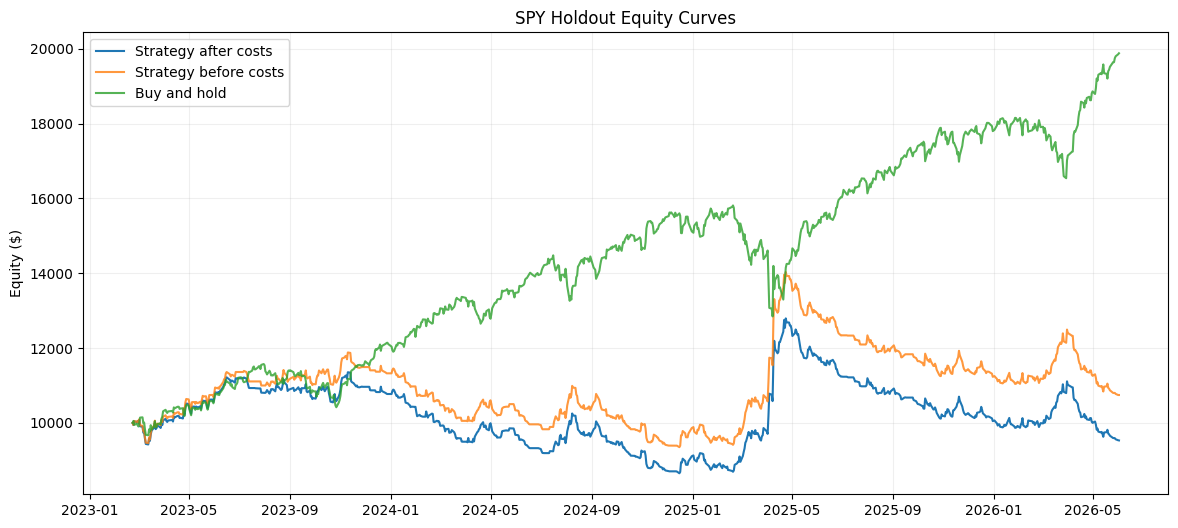

In [4]:
pre_cost_equity = 10_000 * (1 + backtest["strategy_return_before_cost"]).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(backtest["date"], backtest["equity"], label="Strategy after costs")
plt.plot(backtest["date"], pre_cost_equity, label="Strategy before costs", alpha=0.8)
plt.plot(backtest["date"], backtest["buy_hold_equity"], label="Buy and hold", alpha=0.8)
plt.title("SPY Holdout Equity Curves")
plt.ylabel("Equity ($)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

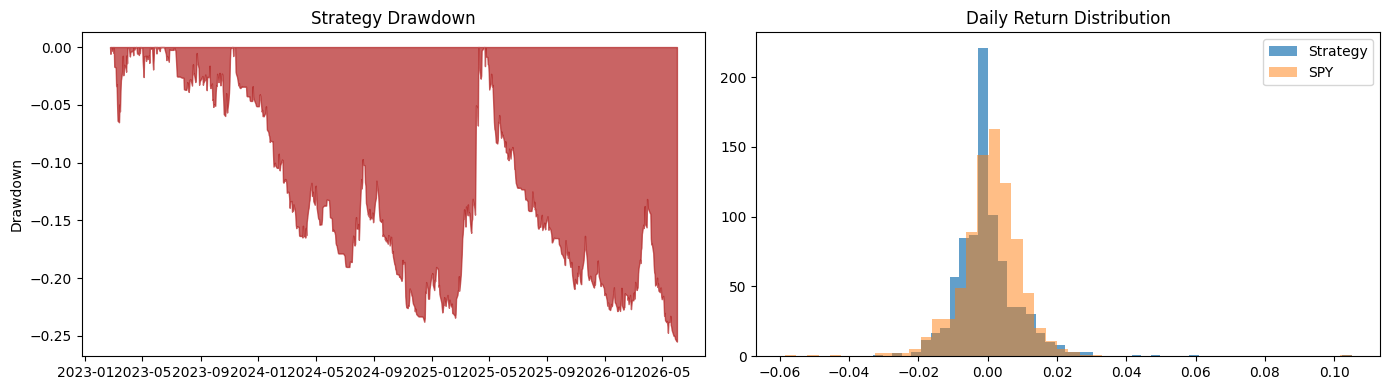

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].fill_between(backtest["date"], backtest["drawdown"], 0, color="firebrick", alpha=0.7)
axes[0].set_title("Strategy Drawdown")
axes[0].set_ylabel("Drawdown")

axes[1].hist(backtest["strategy_return"], bins=50, alpha=0.7, label="Strategy")
axes[1].hist(backtest["asset_return"], bins=50, alpha=0.5, label="SPY")
axes[1].set_title("Daily Return Distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

In [6]:
signal_counts = backtest["prediction"].value_counts().rename_axis("signal").to_frame("count")
signal_counts["proportion"] = signal_counts["count"] / len(backtest)
signal_counts.sort_index()

,count,proportion
signal,,
-1,551,0.670316
0,108,0.131387
1,163,0.198297


## Interpretation

Signals are executed one trading period after prediction. A long-to-short flip incurs twice the one-way transaction cost because the position changes by two units. This holdout backtest is more informative than training performance, but walk-forward validation is still required before drawing broader conclusions.